In [2]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(108)

### Q1

We consider an unknown two-dimensional location
$$
x = (x_1, x_2)^\top \in \mathbb{R}^2.
$$
We use the parametric \emph{banana prior}
$$
p(x_1) = \mathcal{N}(x_1; 0, \sigma_1^2),
$$
$$
p(x_2 \mid x_1) = \mathcal{N}\!\left(x_2;\, b(x_1^2 - \kappa),\, \sigma_2^2\right),
$$
and the one-point range likelihood
$$
p(y \mid x) = \mathcal{N}\!\left(y;\, \lVert x - s \rVert_2,\, \sigma_y^2\right).
$$
(where $x = (x_1, x_2) $)

For this coursework, we use
$$
\sigma_1 = 2,\quad
b = 0.25,\quad
\kappa = 4,\quad
\sigma_2 = 0.3,\quad
s = (0,0)^\top,\quad
y = 4.5,\quad
\sigma_y = 0.2.
$$

This is a Bayesian estimation problem, where we are trying to derive the posterior distribution $p(x \mid y)$ which represents our uncertainty of the 2D location given a noisy range measurement y given by the sensor (we assume it is centered at the origin).

Let's derive the target posterior explicitly using Bayes rule (and plugging all the parameters w already set to predefined constants):

$$
\bar{p}_\star(x \mid y) = p(x)p(y \mid x) = p(x_1)p(x_2 \mid x_1) =
$$
$$ 
\mathcal{N}(x_1; 0, \sigma_1^2)\mathcal{N}\!\left(x_2;\, b(x_1^2 - \kappa),\sigma_2^2\right)\mathcal{N}\!\left(y;\, \lVert x - s \rVert_2,\, \sigma_y^2\right) = 
$$

$$
\mathcal N(x_1; 0, 4)\;
\mathcal N\!\left(x_2;\, 0.25(x_1^2 - 4),\, 0.09\right)\;
\mathcal N\!\left(4.5;\, \sqrt{x_1^2 + x_2^2},\, 0.04\right) \propto
$$
$$
\exp\!\left(-\frac{x_1^2}{8}\right)
\exp\!\left(
-\frac{\left[x_2 - 0.25(x_1^2 - 4)\right]^2}{0.18}
\right)
\exp\!\left(
-\frac{\left[4.5 - \sqrt{x_1^2 + x_2^2}\right]^2}{0.08}
\right).
$$

It is convinient to also have the log-density:

$$
\log(\bar(p)_\star(x \mid y)) =  -\frac{x_1^2}{8}-\frac{\left[x_2 - 0.25(x_1^2 - 4)\right]^2}{0.18}-\frac{\left[4.5 - \sqrt{x_1^2 + x_2^2}\right]^2}{0.08}
$$

In [12]:
# banana function for testing MCMC
def log_banana(x1, x2):
    return -x1**2 / 8 - (x2 - 0.25*(x1**2-4))**2 / 0.18

def log_likelihood(x1, x2, y=4.5):
    return - (y-np.sqrt(x1**2 + x2**2))**2 / 0.08

def log_posterior(x1, x2, y=4.5):
    return log_banana(x1, x2) + log_likelihood(x1, x2, y)

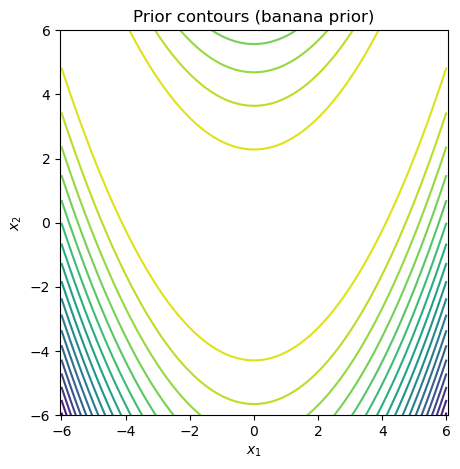

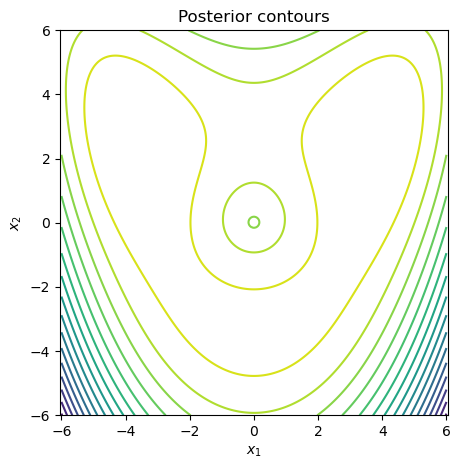

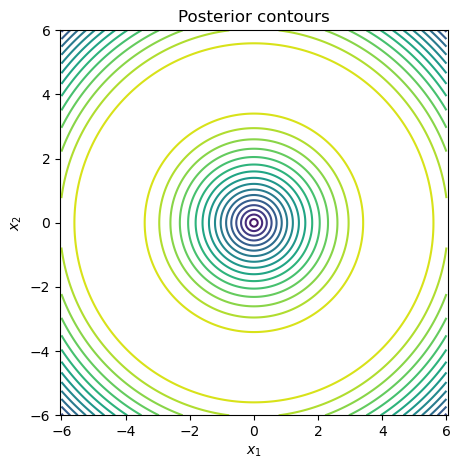

In [11]:
# grid limits
x1_min, x1_max = -6, 6
x2_min, x2_max = -6, 6

n = 300  # grid resolution
x1 = np.linspace(x1_min, x1_max, n)
x2 = np.linspace(x2_min, x2_max, n)
X1, X2 = np.meshgrid(x1, x2)

log_pior = log_banana(X1, X2)
log_lhd = log_likelihood(X1, X2)
log_post = log_posterior(X1, X2)

# Plot the countors:

plt.figure(figsize=(5, 5))
plt.contour(X1, X2, log_pior, levels=20)
plt.title("Prior contours (banana prior)")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.axis("equal")
plt.show()

plt.figure(figsize=(5, 5))
plt.contour(X1, X2, log_lhd, levels=20)
plt.title("Posterior contours")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.axis("equal")
plt.show()

plt.figure(figsize=(5, 5))
plt.contour(X1, X2, log_post, levels=20)
plt.title("Posterior contours")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.axis("equal")
plt.show()



### 1(b): Deriving $\nabla_x \log(p(x \mid y))$

$$
\nabla_x \log \bar p(x_1,x_2 \mid y)
=
\begin{pmatrix}
\displaystyle \frac{\partial}{\partial x_1} \log \bar p(x_1,x_2 \mid y) \\
\displaystyle \frac{\partial}{\partial x_2} \log \bar p(x_1,x_2 \mid y)
\end{pmatrix}.
$$

$$
\frac{\partial}{\partial x_1} \log \bar p(x_1,x_2 \mid y)
=
-\frac{2x_1}{8}
+
\frac{0.25 \cdot 2x_1}{0.18} \cdot
2 \left[x_2 - 0.25(x_1^2 - 4)\right]
+
2 \cdot \frac{4.5 - \sqrt{x_1^2 + x_2^2}}{0.08}
\frac{2x_1 \cdot 0.5}{\sqrt{x_1^2 + x_2^2}}.
$$

$$
\frac{\partial}{\partial x_2} \log \bar p(x_1,x_2 \mid y)
=
0 -\frac{2}{0.18}
\left[x_2 - 0.25(x_1^2 - 4)\right]
+
2 \cdot \frac{4.5 - \sqrt{x_1^2 + x_2^2}}{0.08}
\frac{2x_2 \cdot 0.5}{\sqrt{x_1^2 + x_2^2}}.
$$

Simplifying the coefficients leeds to:

$$
\nabla_x \log \bar p(x_1,x_2 \mid y)
=
\begin{pmatrix}
-\dfrac{x_1}{4}
+ \dfrac{x_1}{0.18}\left[x_2 - 0.25(x_1^2 - 4)\right]
+ \dfrac{4.5 - \sqrt{x_1^2 + x_2^2}}{0.08}
\dfrac{2x_1}{\sqrt{x_1^2 + x_2^2}}
\\
-\dfrac{1}{0.09}\left[x_2 - 0.25(x_1^2 - 4)\right]
+ \dfrac{4.5 - \sqrt{x_1^2 + x_2^2}}{0.08}
\dfrac{2x_2}{\sqrt{x_1^2 + x_2^2}}
\end{pmatrix}.
$$

### 1(c): Random Walk Metropolis-Hastings

Our aim is to extimate location, so our target density is $p(x_1, x_2 \mid y)$.

We will use normal proposal, since it is symmetric, easy to sample and is supported on the whole $\mathbb{R}^2$.

$$
q(x|x') = \mathcal{N}(x; x', \Sigma)
$$